# EEG Lab — Notebook 4/5
## From continuous signal to ERP: epoching, averaging and the P300

**Goals**
- Reconstruct the **events** from the trigger channel (D11 port)
- **Cut** the signal into **epochs** locked to each stimulus (-200 to +800 ms)
- Apply a **baseline correction**
- Perform a simple **artifact rejection**
- **Average** the epochs by condition → make the **P300** emerge
- Compare **targets** vs **standards** at the **Pz** electrode

This is the heart of the lab: we turn a noisy signal into a clean, interpretable average brain response.


### 1. Load the filtered signal

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('oddball_data_filtered.npy')
channels = list(np.load('oddball_channels.npy'))
fs = 250

eeg = data[:-1]
trig = data[-1]
print(f"Filtered EEG: {eeg.shape} | fs = {fs} Hz")

Filtered EEG: (8, 40000) | fs = 250 Hz


### 2. Reconstruct the events from the trigger channel
The trigger channel is `1` (standard) or `2` (target) at the exact moment of each stimulus. We recover these positions and codes.

In [2]:
positions = np.where(trig > 0)[0]       # indices where there is a stimulus
codes = trig[positions].astype(int)     # 1 or 2

print(f"Total number of stimuli: {len(positions)}")
print(f"  standards (code 1): {np.sum(codes == 1)}")
print(f"  targets (code 2)  : {np.sum(codes == 2)}")
print(f"\nFirst 5 events (position, code):")
for p, c in zip(positions[:5], codes[:5]):
    print(f"  sample {p} (t={p/fs:.2f}s) -> {'target' if c==2 else 'standard'}")

Total number of stimuli: 200
  standards (code 1): 169
  targets (code 2)  : 31

First 5 events (position, code):
  sample 25 (t=0.10s) -> standard
  sample 225 (t=0.90s) -> standard
  sample 425 (t=1.70s) -> standard
  sample 625 (t=2.50s) -> standard
  sample 825 (t=3.30s) -> standard


### 3. Define the epoch window
We cut around each stimulus: from **-200 ms** (before) to **+800 ms** (after).
- The **before** part (-200 to 0 ms) serves as the **baseline** (the brain "at rest").
- The **after** part contains the response (N100, P300...).

In [3]:
t_before = 0.2    # 200 ms before the stimulus
t_after = 0.8     # 800 ms after

n_before = int(t_before * fs)   # = 50 samples
n_after = int(t_after * fs)     # = 200 samples
n_epoch = n_before + n_after    # total length of an epoch

# Time vector of the epoch, in milliseconds (0 = moment of the stimulus)
time_ms = (np.arange(-n_before, n_after) / fs) * 1000

print(f"Each epoch: {n_epoch} samples ({t_before+t_after:.1f} s)")
print(f"Time vector: from {time_ms[0]:.0f} ms to {time_ms[-1]:.0f} ms")

Each epoch: 250 samples (1.0 s)
Time vector: from -200 ms to 796 ms


### 4. Cut the signal into epochs
For each stimulus, we extract the corresponding portion of signal, across **all channels**.

In [4]:
epochs = []      # list of epochs (each: 8 channels x n_epoch)
labels = []      # 1=standard, 2=target

for p, c in zip(positions, codes):
    start = p - n_before
    end   = p + n_after
    # we skip stimuli too close to the edges (incomplete epoch)
    if start < 0 or end > eeg.shape[1]:
        continue
    epochs.append(eeg[:, start:end])
    labels.append(c)

epochs = np.array(epochs)   # shape: (n_epochs, 8 channels, n_epoch)
labels = np.array(labels)
print(f"Epochs extracted: {epochs.shape}")
print(f"  -> {epochs.shape[0]} epochs, {epochs.shape[1]} channels, {epochs.shape[2]} points")

Epochs extracted: (198, 8, 250)
  -> 198 epochs, 8 channels, 250 points


### 5. Baseline correction
For each epoch and each channel, we subtract the **mean of the pre-stimulus period** (-200 to 0 ms). This way all epochs start at the same zero level.

In [5]:
# mean over the first n_before points = baseline
baseline = epochs[:, :, :n_before].mean(axis=2, keepdims=True)
epochs_corr = epochs - baseline
print("Baseline correction applied.")
print(f"Check: mean pre-stimulus ~ {epochs_corr[:, :, :n_before].mean():.4f} uV (~ 0)")

Baseline correction applied.
Check: mean pre-stimulus ~ 0.0000 uV (~ 0)


### 6. Simple artifact rejection
An epoch whose amplitude exceeds a **threshold** (e.g. ±100 µV) probably contains an artifact (blink, movement). We remove it.

In [6]:
THRESHOLD = 100  # uV

# maximum absolute amplitude of each epoch (across all channels)
max_amp = np.abs(epochs_corr).max(axis=(1, 2))
keep = max_amp < THRESHOLD

print(f"Epochs before rejection: {len(epochs_corr)}")
print(f"Epochs rejected (> {THRESHOLD} uV): {np.sum(~keep)}")
print(f"Epochs kept: {np.sum(keep)}")

epochs_clean = epochs_corr[keep]
labels_clean = labels[keep]

Epochs before rejection: 198
Epochs rejected (> 100 uV): 0
Epochs kept: 198


### 7. Average by condition → the ERP
We separate the **target** and **standard** epochs, then **average** each group. Averaging attenuates the random noise and reveals the common response: the **ERP**.

In [7]:
idx_pz = channels.index('Pz')

epochs_target   = epochs_clean[labels_clean == 2]
epochs_standard = epochs_clean[labels_clean == 1]

# ERP = mean of the epochs, here for Pz
erp_target   = epochs_target[:, idx_pz, :].mean(axis=0)
erp_standard = epochs_standard[:, idx_pz, :].mean(axis=0)

print(f"Target ERP  : mean of {len(epochs_target)} epochs")
print(f"Standard ERP: mean of {len(epochs_standard)} epochs")

Target ERP  : mean of 31 epochs
Standard ERP: mean of 167 epochs


### 8. Visualize the P300 at Pz
We plot both ERPs. We expect a **positive bump around 300–500 ms**, larger for the **targets**.

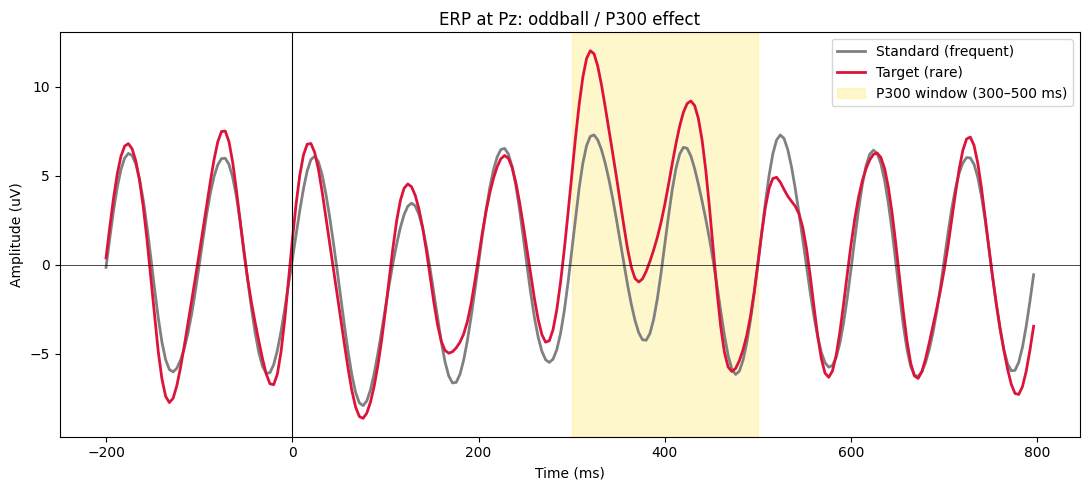

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(time_ms, erp_standard, label='Standard (frequent)', color='gray', lw=2)
plt.plot(time_ms, erp_target, label='Target (rare)', color='crimson', lw=2)

plt.axvline(0, color='black', lw=0.8)               # moment of the stimulus
plt.axhline(0, color='black', lw=0.5)
plt.axvspan(300, 500, color='gold', alpha=0.2, label='P300 window (300–500 ms)')

plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (uV)')
plt.title('ERP at Pz: oddball / P300 effect')
plt.legend()
plt.tight_layout()
plt.show()

### 9. Measure the P300 amplitude
We measure the mean amplitude in the 300–500 ms window for each condition, and their difference (the **oddball effect**).

In [9]:
window = (time_ms >= 300) & (time_ms <= 500)

amp_target   = erp_target[window].mean()
amp_standard = erp_standard[window].mean()

print(f"P300 amplitude (300–500 ms) at Pz:")
print(f"  Target  : {amp_target:.2f} uV")
print(f"  Standard: {amp_standard:.2f} uV")
print(f"  Effect (target - standard): {amp_target - amp_standard:.2f} uV")
print(f"\nThe P300 is much larger for the rare targets: that's the expected effect!")

P300 amplitude (300–500 ms) at Pz:
  Target  : 3.27 uV
  Standard: 0.97 uV
  Effect (target - standard): 2.30 uV

The P300 is much larger for the rare targets: that's the expected effect!


### 10. Save the epochs for Notebook 5

In [10]:
np.save('epochs.npy', epochs_clean)
np.save('labels.npy', labels_clean)
np.save('time_ms.npy', time_ms)
print("Clean epochs saved for the advanced analysis (Notebook 5).")

Clean epochs saved for the advanced analysis (Notebook 5).


---
### ✏️ Exercises
1. Plot the target vs standard ERP at the **Cz** electrode. Is the effect visible there too?
2. Vary the rejection `THRESHOLD` (50 µV, 150 µV). How many epochs are kept?
3. At what **latency** (in ms) does the target ERP reach its maximum? (hint: `time_ms[np.argmax(erp_target)]`)

### 🔑 Key takeaways
- An **epoch** = a chunk of signal locked to a stimulus (-200 to +800 ms).
- The **baseline correction** brings each epoch to zero before the stimulus.
- **Averaging** makes the **ERP** emerge by eliminating the random noise.
- The **P300** is larger for the **rare targets**: that's the **oddball effect**.
